# Day 08. Exercise 00
# Binary classifier. Logistic regression

## 0. Imports

In [105]:
!pip install -U scikit-learn

  Using cached joblib-1.5.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 928.0 kB/s eta 0:00:00a 0:00:01
Using cached joblib-1.5.1-py3-none-any.whl (307 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from random import randint

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## 1. Preprocessing

- Get the data from the file [`checker-timestamp.csv`](https://drive.google.com/file/d/1pooM4cITtG249msX3GK_6W0eEiblzAf5/view?usp=sharing).


- Create a dataframe `df` with the columns: `date`, `am`, `pm`, `target`, where `date` is the date of the day, `am` is the number of the commits during the day before midday (integer), `pm` is the number of commits during the day after midday (integer), `target` is weekend/working_day.

In [266]:
df = pd.read_csv("../data/checker_timestamp.csv")

In [267]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["date"] = df["timestamp"].dt.date
df["daytime"] = df["timestamp"].dt.hour < 12

In [268]:
agg_func = {"date": "count"}
df["count"] = df.groupby("date")["date"].transform("count")
df["am"] = df[df["daytime"] == True].groupby("date")["date"].transform("count")
df["pm"] = df[df["daytime"] == False].groupby("date")["date"].transform("count")
df = df.fillna(0)

df.loc[df["am"] == 0, "am"] = df["count"] - df["pm"]
df.loc[df["pm"] == 0, "pm"] = df["count"] - df["am"]

df.loc[df["timestamp"].dt.dayofweek < 5, "target"] = "working day"
df.loc[df["timestamp"].dt.dayofweek >= 5, "target"] = "weekend"

df = df[["date", "am", "pm", "target"]].copy()
df = df.drop_duplicates()

In [269]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35 entries, 0 to 3158
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    35 non-null     object 
 1   am      35 non-null     float64
 2   pm      35 non-null     float64
 3   target  35 non-null     object 
dtypes: float64(2), object(2)
memory usage: 1.4+ KB


## 2. Exploratory analysis

- Create a plot where `x` is am, `y` is pm, each dot is a day, working days and weekends must have different colors.


- By looking at the graph do you think it will be easy to classify the days having those two features? Put your answer in the markdown cell in the end of that sectioin: "yes, it is easy" or "no, it is not easy".

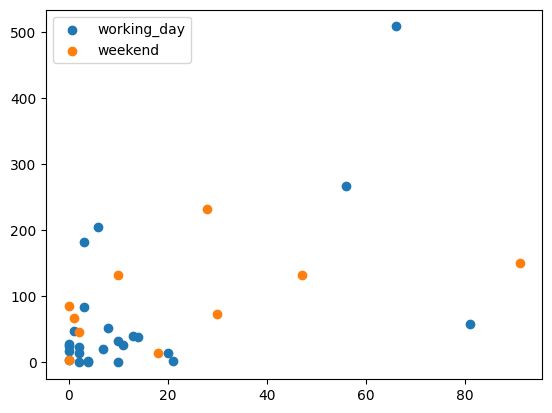

In [270]:
working_days = df[df["target"] == "working day"]
weekend = df[df["target"] == "weekend"]

plt.scatter(x=working_days["am"], y=working_days["pm"], label="working_day")
plt.scatter(x=weekend["am"], y=weekend["pm"], label="weekend")
plt.legend(loc="upper left")
plt.show()


Answer: no, it is not easy

## 3. Logistic regression

- Train logistic regression on your data using `am` and `pm`, parameters are: `random state=21`, `fit_intercept=False`.


- Make predictions for every day of your dataset and add them to your dataframe with the column name `predict`.


- Save the dataframe into a file in the subfolder of the day `data` with the name `am_pm.csv`.


- Draw another plot like you did before, but the color should be taken from the `predict`.


- By looking at the graph do you think if it made good predictions? Put your answer in the markdown cell in the end of that section: "yes, it is good"; "no, it is not good".

In [249]:
X_train = df.iloc[:, 1:3]
y_train = df.iloc[:, 3]

In [275]:
model = LogisticRegression(random_state=21, fit_intercept=False)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,False
,intercept_scaling,1
,class_weight,None
,random_state,21
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [276]:
y_pred = model.predict(X_train)
df["predict"] = y_pred
df

,date,am,pm,target,predict
0,2020-04-17,21.0,2.0,working day,weekend
23,2020-04-18,1.0,68.0,weekend,working day
92,2020-04-19,18.0,15.0,weekend,working day
125,2020-04-20,2.0,23.0,working day,working day
150,2020-04-21,0.0,25.0,working day,working day
175,2020-04-22,0.0,28.0,working day,working day
203,2020-04-23,10.0,33.0,working day,working day
246,2020-04-24,2.0,14.0,working day,working day
262,2020-04-25,30.0,74.0,weekend,working day
366,2020-04-26,28.0,233.0,weekend,working day


In [277]:
df.to_csv("../data/am_pm.csv", index=False)

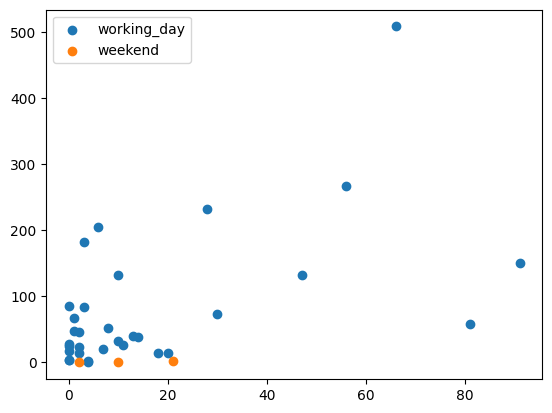

In [278]:
working_days = df[df["predict"] == "working day"]
weekend = df[df["predict"] == "weekend"]

plt.scatter(x=working_days["am"], y=working_days["pm"], label="working_day")
plt.scatter(x=weekend["am"], y=weekend["pm"], label="weekend")
plt.legend(loc="upper left")
plt.show()

Do you think if it made good predictions? No, it is not good 

## 4. Evaluation

- Calculate `accuracy` for your predictions.


- Calculate `accuracy` for the naive case when each of your prediction is the value of your most popular class of the day.


- Comparing the accuracies do you think that the classifier made good predictions? Put your answer in the markdown cell in the end of the secion: "yes, it is good"; "no, it is not good".

In [279]:
#prediction
accuracy = accuracy_score(df.iloc[:, 3], y_pred)
accuracy

0.6285714285714286

In [280]:
#naive_prediction
most_common_day = df["target"].mode()[0]
df["naive_predict"] = most_common_day 
accuracy = accuracy_score(df.iloc[:, 3], df["naive_predict"].to_list())
accuracy

0.7142857142857143

Do you think that the classifier made good predictions? No, it is not good